In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
titanic = pd.read_csv("https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv")

In [3]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
titanic = titanic.drop(columns=['name', 'ticket', 'cabin', 'embarked', 'boat', 'home.dest', 'body'])

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   fare      1308 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 71.7+ KB


In [6]:
titanic.isna().sum()

pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
fare          1
dtype: int64

In [7]:
from sklearn.impute import SimpleImputer

In [8]:
im = SimpleImputer(strategy='mean')

In [9]:
im.fit(titanic[['age', 'fare']])

SimpleImputer()

In [10]:
titanic[['age', 'fare']] = im.transform(titanic[['age', 'fare']])

In [11]:
titanic.isna().sum()

pclass      0
survived    0
sex         0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

In [12]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   fare      1309 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 71.7+ KB


In [13]:
titanic = pd.get_dummies(titanic, drop_first=True)

In [14]:
titanic

,pclass,survived,age,sibsp,parch,fare,sex_male
0,1,1,29.000000,0,0,211.3375,0
1,1,1,0.916700,1,2,151.5500,1
2,1,0,2.000000,1,2,151.5500,0
3,1,0,30.000000,1,2,151.5500,1
4,1,0,25.000000,1,2,151.5500,0
...,...,...,...,...,...,...,...
1304,3,0,14.500000,1,0,14.4542,0
1305,3,0,29.881135,1,0,14.4542,0
1306,3,0,26.500000,0,0,7.2250,1
1307,3,0,27.000000,0,0,7.2250,1


In [15]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   age       1309 non-null   float64
 3   sibsp     1309 non-null   int64  
 4   parch     1309 non-null   int64  
 5   fare      1309 non-null   float64
 6   sex_male  1309 non-null   uint8  
dtypes: float64(2), int64(4), uint8(1)
memory usage: 62.8 KB


# Erstellen der Feature-Matrix (X) und des Label-Vektors (y)

In [16]:
X = titanic.drop(columns="survived")
y = titanic['survived']

# Train Test Split

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Vergleich mit Dummy Classifier

In [19]:
from sklearn.dummy import DummyClassifier

In [20]:
dummy_clf = DummyClassifier(strategy="most_frequent")

In [21]:
dummy_clf.fit(X_train, y_train)

DummyClassifier(strategy='most_frequent')

In [22]:
y_pred = dummy_clf.predict(X_test)

In [23]:
from sklearn.metrics import classification_report

In [24]:
print(classification_report(y_test, y_pred, target_names = ['dead', 'survived']))

              precision    recall  f1-score   support

        dead       0.56      1.00      0.72        73
    survived       0.00      0.00      0.00        58

    accuracy                           0.56       131
   macro avg       0.28      0.50      0.36       131
weighted avg       0.31      0.56      0.40       131



/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Grid Search für Entscheidungsbäume

## Initialisieren des Entscheidungsbaum

In [25]:
from sklearn.tree import DecisionTreeClassifier

In [26]:
clf = DecisionTreeClassifier()

## Grid Search

In [27]:
params = {'max_depth': np.arange(1,10,1),
         'criterion': ['gini', 'entropy']}

In [28]:
from sklearn.model_selection import GridSearchCV

In [29]:
grid_clf = GridSearchCV(clf, param_grid=params, scoring="accuracy", 
                        return_train_score=True, verbose=1, cv=10, n_jobs=-1)

In [30]:
grid_clf.fit(X_train, y_train)

Fitting 10 folds for each of 18 candidates, totalling 180 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
             return_train_score=True, scoring='accuracy', verbose=1)

# Untersuchung der Grid Search Ergebnisse

In [31]:
grid_clf.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [32]:
grid_clf.best_score_

0.812277270751847

In [33]:
df_cv_results = pd.DataFrame(grid_clf.cv_results_)

In [34]:
df_cv_results.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_criterion', 'param_max_depth', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'split5_test_score', 'split6_test_score',
       'split7_test_score', 'split8_test_score', 'split9_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'split5_train_score',
       'split6_train_score', 'split7_train_score', 'split8_train_score',
       'split9_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

# Visualisierung der Grid Search Ergebnisse

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

<AxesSubplot:xlabel='param_max_depth', ylabel='mean_test_score'>

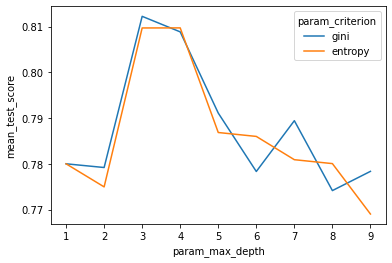

In [36]:
sns.lineplot(x="param_max_depth", y="mean_test_score", 
             hue='param_criterion', data=df_cv_results)

<AxesSubplot:xlabel='param_max_depth', ylabel='mean_train_score'>

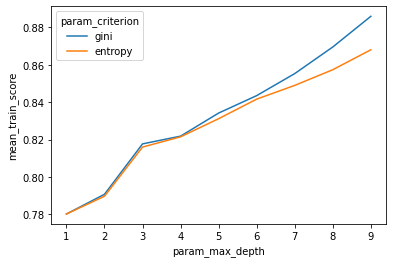

In [37]:
sns.lineplot(x="param_max_depth", y="mean_train_score", 
             hue='param_criterion', data=df_cv_results)

In [38]:
best_clf = grid_clf.best_estimator_

In [39]:
best_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

* y_pred
* classification_report
* Confusion Matrix
* Baum ausgeben 